In [1]:
import sys
sys.path.append('../..')
from utils.data import RK4DataGenerator, stack_real_values, mono_beta, sin_beta
import utils.plotting as plotting
import numpy as np
import pandas as pd

2026-05-24 11:41:05.701288: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-24 11:41:05.701546: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 11:41:05.734673: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 11:41:06.672733: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
t_0, t_f, N = 0, 50, 100
nop_data = 50
S0, I0, R0 = 99, 1, 0
noise_std = N * 0.00
data_t = np.linspace(t_0, t_f, nop_data)

In [3]:
sin_rkdata = RK4DataGenerator(sin_beta, 
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)

In [4]:
sin_sir_data = sin_rkdata.generate(data_t)

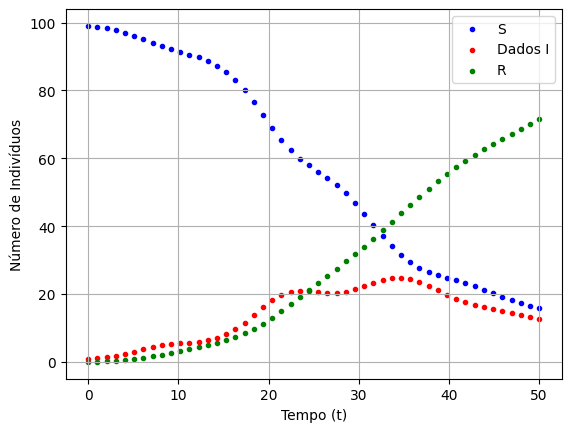

In [5]:
plotting.plot_rk_data(data_t, sin_sir_data, figname="rk-data-sin-beta")

In [6]:
mono_rkdata = RK4DataGenerator(mono_beta, 
    t_0=t_0, 
    t_f=t_f, 
    N=N, 
    S0=S0, I0=I0, R0=R0
)

In [7]:
mono_sir_data = mono_rkdata.generate(data_t)

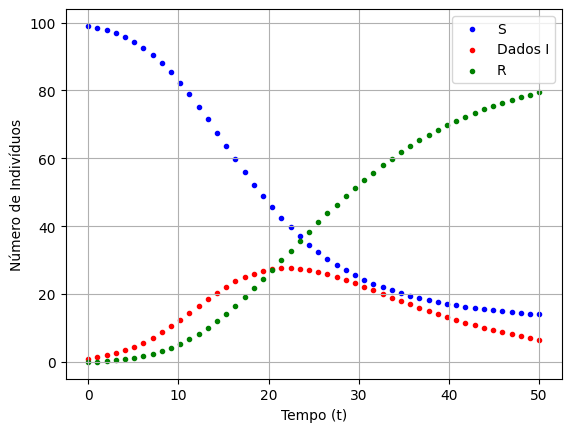

In [8]:
plotting.plot_rk_data(data_t, mono_sir_data, figname="rk-data-mono-beta")

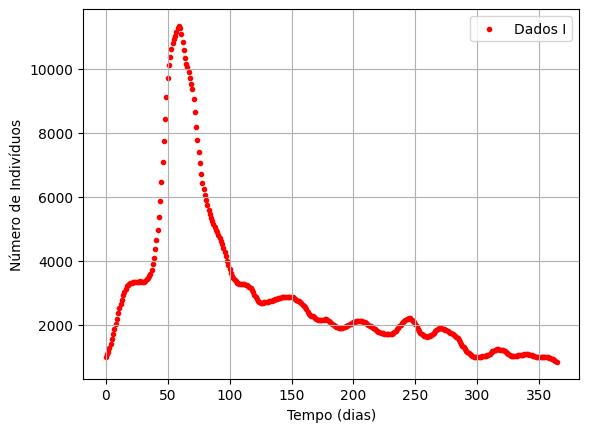

In [9]:
df = pd.read_csv("../../data/sir-am-14d.csv")
I_data = df["I"].to_numpy()
t_0, t_f = 0, len(I_data) - 1
data_t = np.linspace(t_0, t_f, len(I_data))
plotting.plot_prevalence_data(data_t, I_data, 
    xlabel="Tempo (dias)",
    figname="smoothed-data-sus-AM-2023")

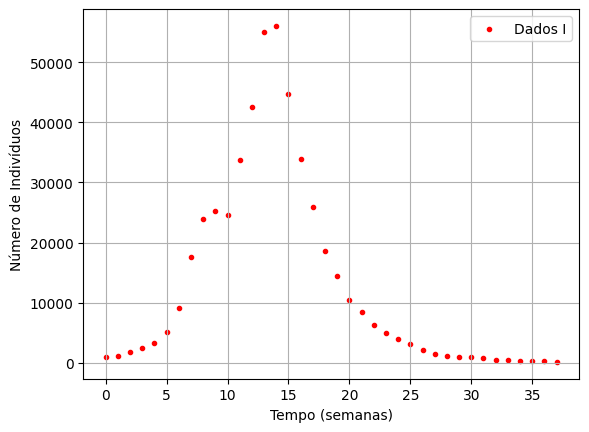

In [10]:
df = pd.read_csv("../../data/FlunetData_United States of America_All Sites_for_28 October 2024 to 20 October 2025.csv")
df = df.sort_values("Week start date (ISO 8601 calendar)")
df = df[df["Surveillance site type"] == "Non-sentinel"]

I_data = df["Influenza positive"].to_numpy()

t_0, t_f = 0, len(I_data) - 1
data_t = np.linspace(t_0, t_f, len(I_data))
N = 341784857 # population size
gamma = 1

plotting.plot_prevalence_data(data_t, I_data, 
    xlabel="Tempo (semanas)", 
    figname="data-eua-2025")

In [11]:
from utils.data import apply_savgol_filter

humidity = pd.read_csv("../../data/daily_mean_humidity.csv")
humidity_values = humidity.to_numpy()[:,1].astype("float64")
humidity_t = np.linspace(0, len(humidity_values) - 1, len(humidity_values))
smoothed_humidity_values = apply_savgol_filter(humidity_t, humidity_values, window=50)

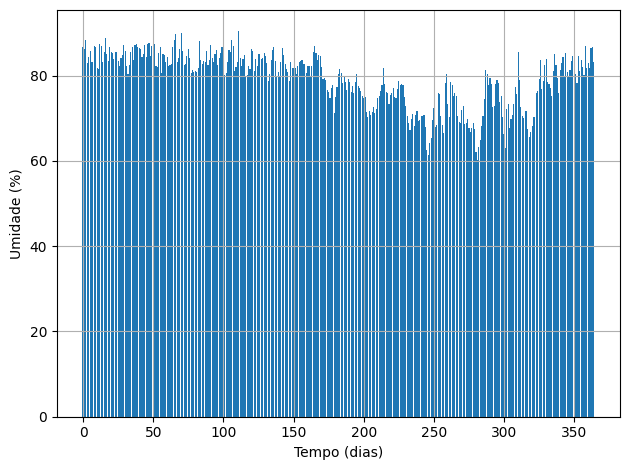

In [12]:
plotting.plot_climate_variable(humidity_values, "Umidade (%)",
    xlabel="Tempo (dias)",
    figname="daily-humidity-AM-2023")

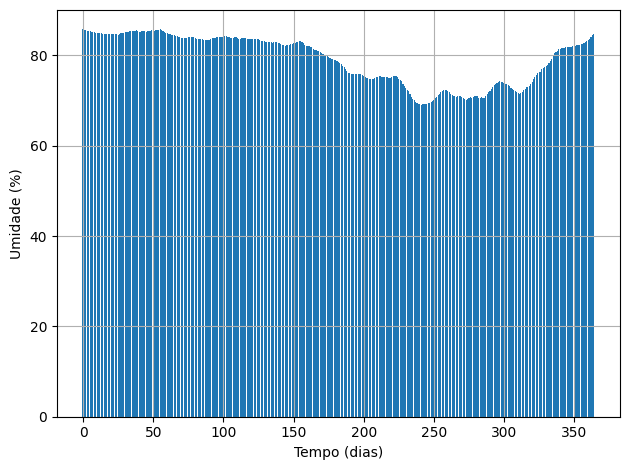

In [13]:
plotting.plot_climate_variable(smoothed_humidity_values, "Umidade (%)",
    xlabel="Tempo (dias)",
    figname="smoothed-daily-humidity-AM-2023")

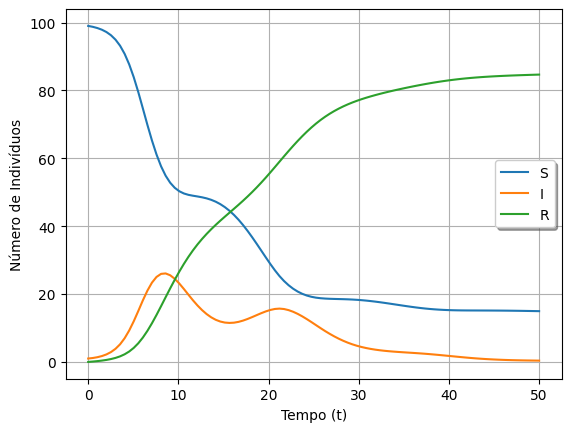

In [40]:
data_t = np.linspace(0, 50, 100)

sin_rkdata = RK4DataGenerator(lambda t: 0.4 * np.sin(0.4 * t) + 0.45, 
    gamma=0.2,
    t_0=0, 
    t_f=50, 
    N=100, 
    S0=S0, I0=I0, R0=R0
)


sin_sir_data = sin_rkdata.generate(data_t)
plotting.plot_rk_curves(data_t, sin_sir_data, figname="sin-beta-data-example")